# Class weight variants

In [ ]:
# ============================================================
# 9. Class-weighted models (no resampling)
# ============================================================

# ---- Decision Tree with class_weight="balanced" ----
dt_weighted = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

param_dist_dt_w = {
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

best_dt_weighted = randomized_search(
    dt_weighted,
    param_dist_dt_w,
    X_train,
    y_train,
    n_iter=10
)

dt_weighted_metrics = evaluate_classifier(
    best_dt_weighted,
    X_val,
    y_val,
    label="DT + class_weight=balanced"
)

# ---- Random Forest with class_weight="balanced" ----
rf_weighted = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

param_dist_rf_w = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

best_rf_weighted = randomized_search(
    rf_weighted,
    param_dist_rf_w,
    X_train,
    y_train,
    n_iter=10
)

rf_weighted_metrics = evaluate_classifier(
    best_rf_weighted,
    X_val,
    y_val,
    label="RF + class_weight=balanced"
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Best CV score: 0.9052108434881724

========== DT + class_weight=balanced ==========

Classification report:
              precision    recall  f1-score   support

           1       0.92      0.93      0.93     42368
           2       0.95      0.93      0.94     56660
           3       0.91      0.90      0.90      7151
           4       0.77      0.84      0.80       550
           5       0.79      0.81      0.80      1898
           6       0.82      0.85      0.84      3473
           7       0.92      0.94      0.93      4102

    accuracy                           0.92    116202
   macro avg       0.87      0.89      0.88    116202
weighted avg       0.92      0.92      0.92    116202

Confusion matrix:
[[39606  2399     6     0    46    20   291]
 [ 3382 52440   284     1   316   196    41]
 [    9   158  6468   107    29   380     0]
 

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Best CV score: 0.9349061962667436

========== RF + class_weight=balanced ==========

Classification report:
              precision    recall  f1-score   support

           1       0.96      0.93      0.94     42368
           2       0.95      0.96      0.95     56660
           3       0.92      0.95      0.94      7151
           4       0.84      0.90      0.87       550
           5       0.89      0.82      0.86      1898
           6       0.88      0.90      0.89      3473
           7       0.96      0.96      0.96      4102

    accuracy                           0.94    116202
   macro avg       0.91      0.92      0.92    116202
weighted avg       0.94      0.94      0.94    116202

Confusion matrix:
[[39481  2694     7     0    20    11   155]
 [ 1641 54370   268     3   151   206    21]
 [    0    76  6809    58    10   198     0]
 [    0     0    40   496     0    14    

In [ ]:
# ============================================================
# 10. XGBoost with class-based sample weights
# ============================================================

# Compute class weights like sklearn's "balanced"
class_counts = y_train.value_counts().sort_index()  # labels 1..7
total_samples = len(y_train)
n_classes = class_counts.shape[0]
class_weights = {
    cls: total_samples / (n_classes * count)
    for cls, count in class_counts.items()
}

# Map each training sample to its class weight
sample_weights_train = y_train.map(class_weights).values

xgb_weighted = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

param_dist_xgb_w = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# We can't pass sample_weight directly into RandomizedSearchCV params,
# so we do manual tuning or a simpler search. To keep it consistent
# with your other code, we can pick a reasonable fixed configuration
# or do a very small manual loop. For simplicity, here we pick one
# configuration and focus on the weighting:

best_xgb_weighted = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

# Fit on label-encoded y (0..6) but with sample weights based on original y_train
best_xgb_weighted.fit(
    X_train_xgb,
    y_train_xgb,
    sample_weight=sample_weights_train
)

xgb_weighted_metrics = evaluate_classifier(
    best_xgb_weighted,
    X_val_xgb,
    y_val,                 # original labels for reporting
    label="XGB + sample weights",
    is_xgb=True
)


========== XGB + sample weights ==========

Classification report:
              precision    recall  f1-score   support

           1       0.82      0.85      0.84     42368
           2       0.90      0.78      0.84     56660
           3       0.86      0.90      0.88      7151
           4       0.79      0.94      0.86       550
           5       0.37      0.97      0.54      1898
           6       0.66      0.93      0.78      3473
           7       0.79      0.99      0.88      4102

    accuracy                           0.83    116202
   macro avg       0.74      0.91      0.80    116202
weighted avg       0.85      0.83      0.83    116202

Confusion matrix:
[[36010  4890    18     0   424    50   976]
 [ 7746 44332   853     0  2608   998   123]
 [    0    23  6425   103    38   562     0]
 [    0     0    15   517     0    18     0]
 [    1    38    13     0  1837     9     0]
 [    0     6   182    34    11  3240     0]
 [   45     1     0     0     2     0  4054]]
M

Extend the results table and plots to include class-weight models

In [ ]:
results_val = pd.DataFrame({
    "Model": [
        "DT + RUS",
        "RF + RUS",
        "XGB + RUS",
        "DT + BalancedBagging",
        "RF + BalancedBagging",
        "XGB + BalancedBagging",
        "DT + class_weight",
        "RF + class_weight",
        "XGB + sample_weights"
    ],
    "Val_ROC_AUC_weighted": [
        rus_dt_metrics["auc"],
        rus_rf_metrics["auc"],
        rus_xgb_metrics["auc"],
        bb_dt_metrics["auc"],
        bb_rf_metrics["auc"],
        bb_xgb_metrics["auc"],
        dt_weighted_metrics["auc"],
        rf_weighted_metrics["auc"],
        xgb_weighted_metrics["auc"]
    ],
    "Val_F1_macro": [
        rus_dt_metrics["f1_macro"],
        rus_rf_metrics["f1_macro"],
        rus_xgb_metrics["f1_macro"],
        bb_dt_metrics["f1_macro"],
        bb_rf_metrics["f1_macro"],
        bb_xgb_metrics["f1_macro"],
        dt_weighted_metrics["f1_macro"],
        rf_weighted_metrics["f1_macro"],
        xgb_weighted_metrics["f1_macro"]
    ],
    "Family": [
        "RUS",
        "RUS",
        "RUS",
        "BalancedBagging",
        "BalancedBagging",
        "BalancedBagging",
        "ClassWeight",
        "ClassWeight",
        "ClassWeight"
    ]
})

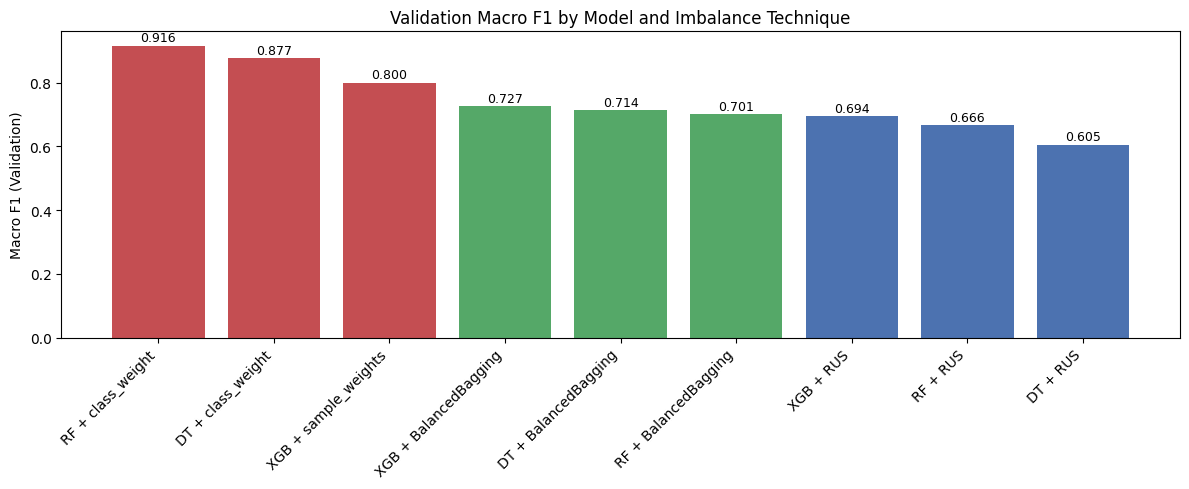

In [ ]:
color_map = {
    "RUS": "#4c72b0",
    "BalancedBagging": "#55a868",
    "ClassWeight": "#c44e52"
}

# Re-create plot_df from the updated results_val to include the 'Family' column
plot_df = results_val.sort_values("Val_F1_macro", ascending=False)

colors = [color_map[f] for f in plot_df["Family"]]

plt.figure(figsize=(12, 5))
bars = plt.bar(
    plot_df["Model"],
    plot_df["Val_F1_macro"],
    color=colors
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Macro F1 (Validation)")
plt.title("Validation Macro F1 by Model and Imbalance Technique")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        height + 0.005,
        f"{height:.3f}",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.show()